In [1]:
# Imports and Configurations
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import time

# Clustering and distance metrics
from dtaidistance import dtw
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score

# Parallelization
import multiprocessing as mp

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

np.random.seed(42)

# Configuration
BENCHMARK      = '^GSPC'
RISK_FREE_RATE = 0.045
START_DATE     = '2005-01-01'
END_DATE       = '2026-01-01'
ROLLING_WINDOW = 52
MIN_HIST       = 400
K_VALUES       = [2, 4, 7]
N_CORES        = 10

# Three-period out-of-sample validation framework (20-year-window)
TRAIN_START = '2005-01-01'
TRAIN_END   = '2010-12-31'   # 6 years
VAL_START   = '2011-01-01'
VAL_END     = '2017-12-31'   # 7 years
TEST_START  = '2018-01-01'
TEST_END    = '2025-12-31'   # 7 years

# Strategy Parameters (tightened version of Notebook 6)
ZSCORE_WINDOW   = 52
VOL_WINDOW      = 26
VOL_THRESHOLD   = 1.5
HIGH_VOL_ENTRY  = 2.25  # was 2.5
LOW_VOL_ENTRY   = 1.25  # was 1.5
STANDARD_ENTRY  = 1.75  # was 2.0
EXIT_THRESHOLD  = 0.5
STOP_LOSS       = 3.25  # was 3.5

print('Notebook 7: DTW vs OCP vs TOP Clustering - S&P 500, 20-Year Three-Period Framework')
print(f'Train:  {TRAIN_START} to {TRAIN_END} (6 years)')
print(f'Val:    {VAL_START} to {VAL_END} (7 years)')
print(f'Test:   {TEST_START} to {TEST_END} (7 years)')

Notebook 7: DTW vs OCP vs TOP Clustering - S&P 500, 20-Year Three-Period Framework
Train:  2005-01-01 to 2010-12-31 (6 years)
Val:    2011-01-01 to 2017-12-31 (7 years)
Test:   2018-01-01 to 2025-12-31 (7 years)


In [2]:
import re

# Retrieving S&P 500 constitutents as of January 1, 2005

# Survivorship-bias free source
hist_url = (
    'https://raw.githubusercontent.com/fja05680/sp500/master/'
    'S%26P%20500%20Historical%20Components%20%26%20Changes.csv'
)

hist = pd.read_csv(hist_url)
hist['date'] = pd.to_datetime(hist['date'])

# Targeting the row closest to our date
target_date = pd.Timestamp('2005-01-01')
snapshot_row = hist[hist['date'] <= target_date].sort_values('date').iloc[-1]

print(f'Using snapshot date: {snapshot_row["date"].date()}')

sp500_tickers_2005 = sorted(snapshot_row['tickers'].split(','))

raw_tickers = sorted(snapshot_row['tickers'].split(','))

# Stipping the dataset's own "-YYYYMM" delisting_date suffix convention
suffix_pattern = re.compile(r'-\d{6}$')

sp500_tickers_2005 = sorted(set(
    suffix_pattern.sub('', t.strip()).replace('.','-')
    for t in raw_tickers
))

n_suffixed = sum(1 for t in raw_tickers if suffix_pattern.search(t.strip()))
print(f'Tickers with a delisting-date suffix in the source data: {n_suffixed}')
print(f'S&P 500 constituents as of {target_date.date()}: {len(sp500_tickers_2005)} stocks')
print(f'\nFirst 10 tickers: {sp500_tickers_2005[:10]}')

Using snapshot date: 2004-12-30
Tickers with a delisting-date suffix in the source data: 179
S&P 500 constituents as of 2005-01-01: 495 stocks

First 10 tickers: ['A', 'AABA', 'AAPL', 'ABC', 'ABI', 'ABKFQ', 'ABS', 'ABT', 'ACS', 'ACV']


In [3]:
# Downloading price data for this S&P 500 205 universe
import yfinance as yf

print(f'Downloading price data for {len(sp500_tickers_2005)} stocks...')
print(f'Period: {START_DATE} to {END_DATE}, weekly (Wednesday), adjusted close\n')

raw = yf.download(
    sp500_tickers_2005,
    start=START_DATE,
    end=END_DATE,
    interval='1wk',
    auto_adjust=True,
    progress=True
)

price_data = raw['Close']
price_data = price_data.resample('W-WED').last()
price_data = price_data.dropna(how='all')

# Dropping any tickers without complete history across the full history
before_drop = price_data.shape[1]
price_data  = price_data.ffill().dropna(axis=1)
after_drop  = price_data.shape[1]

# Dropping any tickers that are flatlined through the end of the series
TAIL_WINDOW = 10

flatlined = []
for t in price_data.columns:
    tail = price_data[t].iloc[-TAIL_WINDOW:]
    if tail.nunique() == t:
        flatlined.append(t)

price_data = price_data.drop(columns=flatlined)
after_drop = price_data.shape[1]

print(f'\nPrice data shape: {price_data.shape}')
print(f'Date range: {price_data.index[0].date()} to {price_data.index[-1].date()}')
print(f'Tickers with complete history: {after_drop} (dropped {before_drop - after_drop} incomplete/delisted)')

dropped_tickers = sorted(set(sp500_tickers_2005) - set(price_data.columns))
print(f'\nDropped tickers ({len(dropped_tickers)}): {dropped_tickers}')
        

Period: 2005-01-01 to 2026-01-01, weekly (Wednesday), adjusted close



$HET: possibly delisted; no price data found  (1wk 2005-01-01 -> 2026-01-01)
$BMET: possibly delisted; no price data found  (1wk 2005-01-01 -> 2026-01-01)
$ESRX: possibly delisted; no price data found  (1wk 2005-01-01 -> 2026-01-01)
$ARNC: possibly delisted; no timezone found      ]  11 of 495 completed
$EOP: possibly delisted; no price data found  (1wk 2005-01-01 -> 2026-01-01)
$CHIR: possibly delisted; no price data found  (1wk 2005-01-01 -> 2026-01-01)
$SFA: possibly delisted; no price data found  (1wk 2005-01-01 -> 2026-01-01)
$AGN: possibly delisted; no timezone found       ]  24 of 495 completed
$BHGE: possibly delisted; no timezone found      ]  25 of 495 completed
$AT: possibly delisted; no timezone found        ]  26 of 495 completed
$CBS: possibly delisted; no timezone found       ]  27 of 495 completed
$EKDKQ: possibly delisted; no timezone found     ]  28 of 495 completed
$EA: possibly delisted; no price data found  (1wk 2005-01-01 -> 2026-01-01) (Yahoo error = "Data doesn'


Price data shape: (1096, 267)
Date range: 2005-01-05 to 2025-12-31
Tickers with complete history: 267 (dropped 228 incomplete/delisted)

Dropped tickers (228): ['AABA', 'ABC', 'ABI', 'ABKFQ', 'ABS', 'ACS', 'ACV', 'ADCT', 'AET', 'AGN', 'ALTR', 'AMCC', 'ANDW', 'ANTM', 'APC', 'APCC', 'APOL', 'ARNC', 'ASN', 'ASO', 'AT', 'AV', 'AVP', 'AW', 'AYE', 'BCR', 'BDK', 'BEAM', 'BHGE', 'BIG', 'BJS', 'BK', 'BLL', 'BLS', 'BMC', 'BMET', 'BMS', 'BNI', 'BOL', 'BR', 'BRCM', 'BSC', 'BUD', 'CA', 'CBE', 'CBS', 'CBSS', 'CCE', 'CCTYQ', 'CEG', 'CFC', 'CHIR', 'CIN', 'CITGQ', 'CMA', 'CMVT', 'CMX', 'COL', 'CPNLQ', 'CPWR', 'CTB', 'CTL', 'CTX', 'CTXS', 'DALRQ', 'DCNAQ', 'DELL', 'DG', 'DJ', 'DOW', 'DPHIQ', 'DYN', 'EA', 'EC', 'EDS', 'EKDKQ', 'EMC', 'EOP', 'ESRX', 'ETFC', 'FDC', 'FDO', 'FII', 'FOXA', 'FRX', 'FSH', 'FSL', 'FTR', 'G', 'GAS', 'GDT', 'GDW', 'GENZ', 'GLK', 'GP', 'GPS', 'GR', 'GTW', 'HCA', 'HCR', 'HES', 'HET', 'HLT', 'HMA', 'HNZ', 'HOT', 'HPC', 'HSH', 'HSP', 'IGT', 'IPG', 'IR', 'JAVA', 'JCP', 'JNS', 'JNY', '

In [4]:
print("""
    Data source limitation note (for methodology section / paper draft):

    yfinance does not serve historical price data for tickers that have 
    been delisted, regardless of how far in the past the requested date 
    range is. This means our S&P 500 2005 universe is effectively: '
    constituents as of Jan 2005 whose historical data remains accessible 
    via Yahoo Finance as of the analysis date' (2026), not strictly 
    'constituents as of Jan 2005.' Companies that were acquired, taken 
    private, or delisted at any point between 2005 and today are absent
    even thought they had complete price history during the actual 
    2005-2025 study window. This effect is matierally more substantial 
    here than in a shorter window, since a 20-year span captures far more 
    corporate turnover.
""")

print("""
    This is a known constraint of free retail data verndors and differs
    from the CRSP/WRDS standard in academic finance, which preserves
    full historical records for delisted securities. Disclosed here as a 
    limitation rather than corrected, due to project resources.
""")


    Data source limitation note (for methodology section / paper draft):

    yfinance does not serve historical price data for tickers that have 
    been delisted, regardless of how far in the past the requested date 
    range is. This means our S&P 500 2005 universe is effectively: '
    constituents as of Jan 2005 whose historical data remains accessible 
    via Yahoo Finance as of the analysis date' (2026), not strictly 
    'constituents as of Jan 2005.' Companies that were acquired, taken 
    private, or delisted at any point between 2005 and today are absent
    even thought they had complete price history during the actual 
    2005-2025 study window. This effect is matierally more substantial 
    here than in a shorter window, since a 20-year span captures far more 
    corporate turnover.


    This is a known constraint of free retail data verndors and differs
    from the CRSP/WRDS standard in academic finance, which preserves
    full historical records for delisted 

In [5]:
# Computing weekly log returns
log_returns = np.log(price_data / price_data.shift(1))

# Computing rolling sharpe ratio (risk-free-rate adjusted)
weekly_rf = RISK_FREE_RATE / 52

rolling_mean = log_returns.rolling(window=ROLLING_WINDOW).mean()
rolling_std = log_returns.rolling(window=ROLLING_WINDOW).std()

sharpe_data = ((rolling_mean - weekly_rf) / rolling_std) * np.sqrt(52)
sharpe_data = sharpe_data.dropna(how='all')

print(f'Sharpe data range: {sharpe_data.shape}')
print(f'Date range: {sharpe_data.index[0].date()} to {sharpe_data.index[-1].date()}')
print(f'\nSample (first 5 stocks, last 5 weeks):')
print(sharpe_data.iloc[-5:, :5])

Sharpe data range: (1044, 267)
Date range: 2006-01-04 to 2025-12-31

Sample (first 5 stocks, last 5 weeks):
Ticker           A   AAPL    ABT    ADBE    ADI
Date                                           
2025-12-03 -0.0083 0.2958 0.2543 -1.5043 0.5756
2025-12-10 -0.1020 0.2253 0.3648 -1.0412 0.5763
2025-12-17 -0.0538 0.0978 0.3282 -0.9179 0.5874
2025-12-24 -0.0515 0.0817 0.2721 -0.9323 0.5483
2025-12-31 -0.1089 0.2162 0.3395 -0.8516 0.5141


In [6]:
# Computing DTW distance matrix for the S&P 500 universe

train_sharpe_data = sharpe_data.loc[TRAIN_START:TRAIN_END]

nan_cols = train_sharpe_data.columns[train_sharpe_data.isna().any()].tolist()
inf_cols = train_sharpe_data.columns[np.isinf(train_sharpe_data).any()].tolist()
bad_cols = sorted(set(nan_cols) | set(inf_cols))
if bad_cols:
    train_sharpe_data = train_sharpe_data.drop(columns=bad_cols)
    print(f'Dropped {bad_cols} for containing NaN/inf values (zero rolling volatility). New shape: {train_sharpe_data.shape}')

tickers = train_sharpe_data.columns.tolist()
n = len(tickers)
print(f'Computing DTW distances for {n} stocks ({n*(n-1)//2} pairs), Train period only...')

# dtaidistance requires float64
series = [train_sharpe_data[t].values.astype(np.float64) for t in tickers]

start_time = time.time()
dtw_distance_matrix = dtw.distance_matrix_fast(series)
elapsed = time.time() - start_time

print(f'\nDTW distance matrix computes in {elapsed:.1f} seconds')
print(f'Matrix shape: {dtw_distance_matrix.shape}')

dtw_distance_matrix[dtw_distance_matrix == np.inf] = 0
dtw_distance_matrix = dtw_distance_matrix + dtw_distance_matrix.T

print(f'\nSample of distance matrix (first 5x5):')
print(pd.DataFrame(dtw_distance_matrix[:5, :5], index=tickers[:5], columns=tickers[:5]))

# Locking the result to disk
np.save('dtw_distance_matrix_sp500_train.npy', dtw_distance_matrix)
pd.Series(tickers).to_csv('dtw_tickers_sp500_train.csv', index=False, header=['ticker'])
print('\nSaved dtw_distance_matrix_sp500_train.npy and dtw_tickers_sp500_train.csv')

Computing DTW distances for 267 stocks (35511 pairs), Train period only...

DTW distance matrix computes in 1.6 seconds
Matrix shape: (267, 267)

Sample of distance matrix (first 5x5):
           A    AAPL     ABT    ADBE     ADI
A     0.0000 14.0768 24.8103 14.6522 16.0921
AAPL 14.0768  0.0000 28.0367 24.1182 22.6598
ABT  24.8103 28.0367  0.0000 12.1187 13.2489
ADBE 14.6522 24.1182 12.1187  0.0000 12.9011
ADI  16.0921 22.6598 13.2489 12.9011  0.0000

Saved dtw_distance_matrix_sp500_train.npy and dtw_tickers_sp500_train.csv


k=2: cluster sizes = [67, 200]
k=4: cluster sizes = [67, 60, 77, 63]
k=7: cluster sizes = [15, 52, 21, 39, 77, 33, 30]


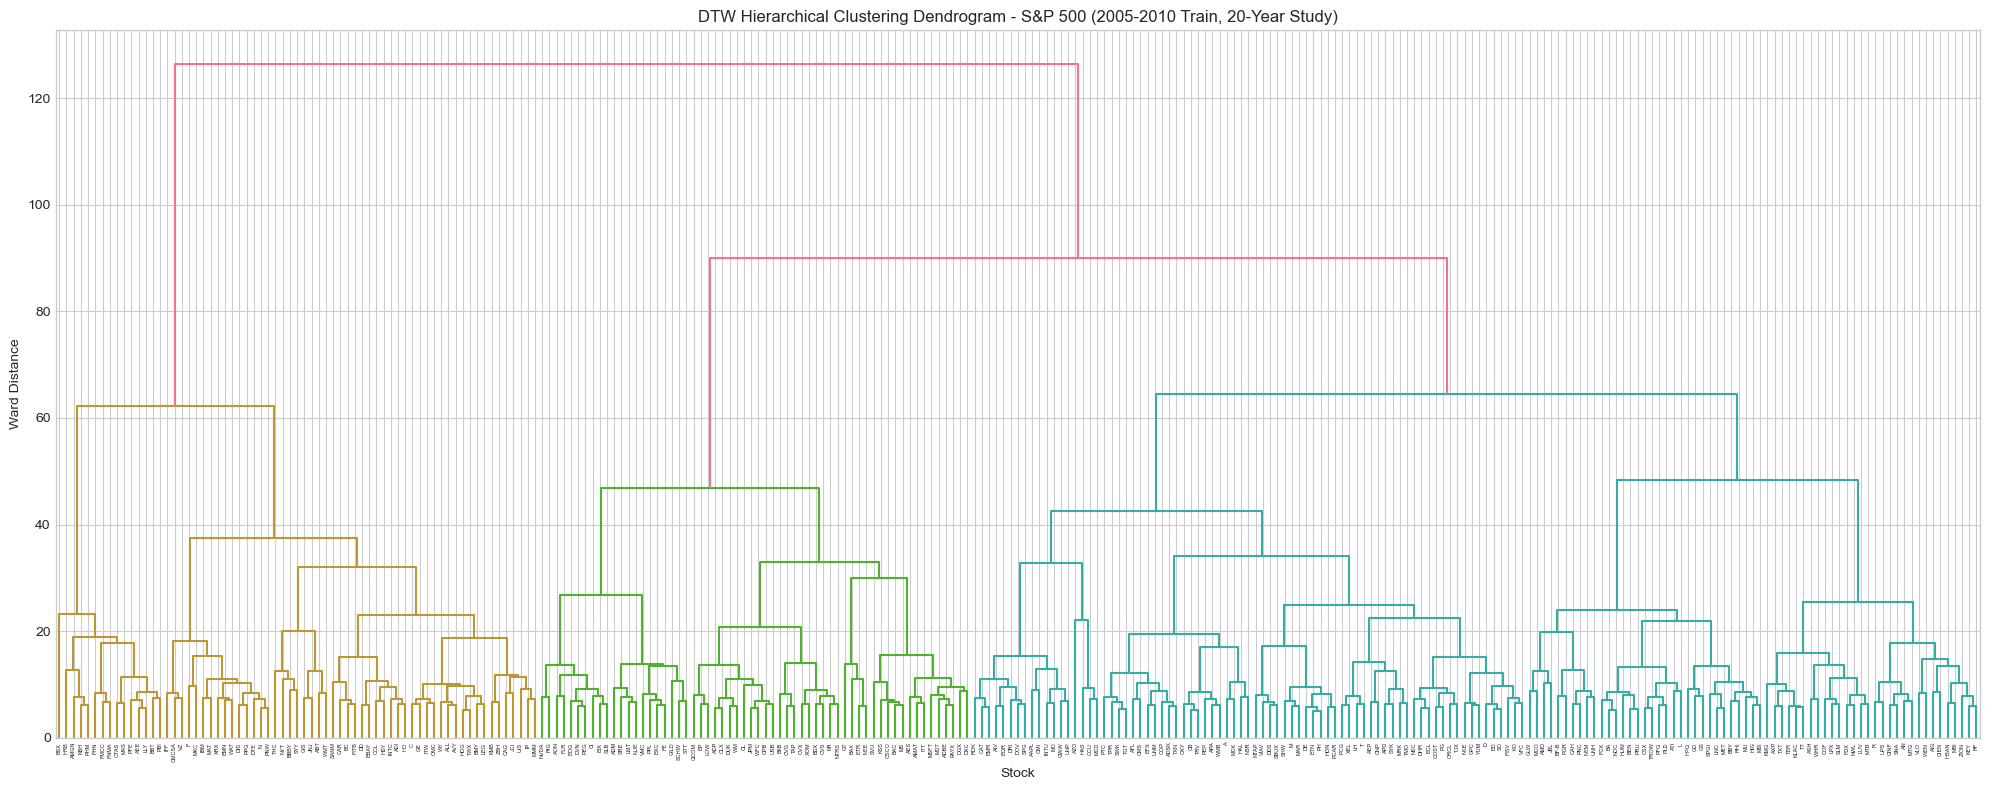


DTW cluster assignments saved to dtw_cluster_df and dtw_cluster_assignments_sp500_20y.csv
  ticker  cluster_k2  cluster_k4  cluster_k7
0      A           2           3           5
1   AAPL           2           3           5
2    ABT           1           1           2
3   ADBE           2           2           4
4    ADI           1           1           2


In [7]:
# DTW hierarchical clustering (k=2, 4, 7), Ward linkage
condensed_dtw = squareform(dtw_distance_matrix)
dtw_linkage = linkage(condensed_dtw, method='ward')

dtw_clusters = {}
for k in K_VALUES:
    dtw_clusters[k] = fcluster(dtw_linkage, t=k, criterion='maxclust')
    sizes = pd.Series(dtw_clusters[k]).value_counts().sort_index()
    print(f'k={k}: cluster sizes = {sizes.tolist()}')

# Dendrogram
fig, ax = plt.subplots(figsize=(20,8))
dendrogram(dtw_linkage, labels=tickers, leaf_rotation=90, leaf_font_size=4, ax=ax)
ax.set_title('DTW Hierarchical Clustering Dendrogram - S&P 500 (2005-2010 Train, 20-Year Study)')
ax.set_xlabel('Stock')
ax.set_ylabel('Ward Distance')
plt.tight_layout()
plt.savefig('dtw_dendrogram_sp500_20y.png', dpi=150, bbox_inches='tight')
plt.show()

# Storing cluster assignments in a DataFrame for later use (cointegration testing)
dtw_clusters_df = pd.DataFrame({'ticker':tickers})
for k in K_VALUES:
    dtw_clusters_df[f'cluster_k{k}'] = dtw_clusters[k]

dtw_clusters_df.to_csv('dtw_cluster_assignments_sp500_20y.csv', index=False)

print(f'\nDTW cluster assignments saved to dtw_cluster_df and dtw_cluster_assignments_sp500_20y.csv')
print(dtw_clusters_df.head())

In [8]:
# Cluster validation indices for DTW clustering
dtw_cvi_results = []

for k in K_VALUES:
    labels = dtw_clusters[k]

    # Silhouette score using DTW distance matrix directly
    sil = silhouette_score(dtw_distance_matrix, labels, metric='precomputed')

    # Calinski-Harabasz and Davies-Bouldin using raw Sharpe ratio scores
    ch = calinski_harabasz_score(train_sharpe_data.T, labels)
    db = davies_bouldin_score(train_sharpe_data.T, labels)

    dtw_cvi_results.append({
        'k': k,
        'silhouette': sil,
        'calinski_harabasz': ch,
        'davies_bouldin': db
    })

    print(f'k={k}: silhouette={sil:.4f}, calinski_harabasz={ch:.2f}, davies_bouldin={db:.4f}')

dtw_cvi_df = pd.DataFrame(dtw_cvi_results)
print('\nDTW Cluster Validation Summary:')
print(dtw_cvi_df)   

k=2: silhouette=0.2113, calinski_harabasz=27.53, davies_bouldin=2.5727
k=4: silhouette=0.1180, calinski_harabasz=22.13, davies_bouldin=2.7211
k=7: silhouette=0.0984, calinski_harabasz=16.18, davies_bouldin=2.7152

DTW Cluster Validation Summary:
   k  silhouette  calinski_harabasz  davies_bouldin
0  2      0.2113            27.5324          2.5727
1  4      0.1180            22.1262          2.7211
2  7      0.0984            16.1798          2.7152


In [9]:
# OCP (Optimal Causal Path) distance function

def ocp_distance(x, y):
    """
    Computes the Optimal Causal Path between two time series,
    by enforcing a causality constaint where j >= i, blocking
    the lower triangle of the cost matrix. This prevents a 
    future observation of x from being matches to a past 
    observation in y, one directional assumption of the lead-lag
    relationship rather than a determination of it.
    """
    n, m = len(x), len(y)
    cost = np.full ((n,m), np.inf)
    cost[0,0] = abs(x[0] - y[0])

    for i in range(n):
        for j in range(m):
            if j < i:
                continue
            if i == 0 and j == 0:
                continue
            candidates = []
            if i > 0:
                candidates.append(cost[i - 1, j])
            if j > 0:
                candidates.append(cost[i, j - 1])
            if i > 0 and j > 0:
                candidates.append(cost[i - 1, j - 1])
            cost[i, j] = abs(x[i] - y[j]) + min(candidates)

    return cost[n - 1, m -1]

def ocp_symmetric(x, y):
    """
    Computes OCP distance in both directions and takes the minimum, 
    improving on Stubinger (2019) who assumes a fixed lead direction.
    """
    return min(ocp_distance(x,y), ocp_distance(y,x))
    

In [10]:
!pip install multiprocess

In [11]:
from multiprocess import Pool

def ocp_pair_worker(args):
    import numpy as np

    def _ocp_distance(x,y):
         n, m = len(x), len(y)
         cost = np.full ((n,m), np.inf)
         cost[0,0] = abs(x[0] - y[0])
         for i in range(n):
            for j in range(m):
                if j < i:
                    continue
                if i == 0 and j == 0:
                    continue
                candidates = []
                if i > 0:
                    candidates.append(cost[i - 1, j])
                if j > 0:
                    candidates.append(cost[i, j - 1])
                if i > 0 and j > 0:
                    candidates.append(cost[i - 1, j - 1])
                cost[i, j] = abs(x[i] - y[j]) + min(candidates)
         return cost[n - 1, m -1]

    i, j, x, y = args
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    d = min(_ocp_distance(x,y), _ocp_distance(y,x))
    return i, j, d

tickers = train_sharpe_data.columns.tolist()
n = len(tickers)

tasks = []
for i in range(n):
    for j in range(i + 1, n):
        x = train_sharpe_data.iloc[:, i].values
        y = train_sharpe_data.iloc[:, j].values
        tasks.append((i , j, x, y))

print(f'Total pairs to compute: {len(tasks)}')
print(f'Using {N_CORES} cores')

start_time = time.time()
ocp_matrix = np.zeros((n,n))

with Pool(processes=N_CORES) as pool:
    completed = 0
    for i, j, d in pool.imap_unordered(ocp_pair_worker, tasks, chunksize=50):
        ocp_matrix[i,j] = d
        ocp_matrix[j,i] = d
        completed += 1
        if completed % 5000 == 0:
            elapsed = time.time() - start_time
            pct = completed / len(tasks) * 100
            eta = (elapsed / completed) * (len(tasks) - completed)
            print(f' {completed:,}/{len(tasks):,} ({pct:.1f}%) - elapsed {elapsed:0f}s - ETA {eta:.0f}s')
        if completed % 10000 == 0:
            np.save('ocp_distance_matrix_sp500_20y_checkpoint.npy', ocp_matrix)
            print(f'  [checkpoint saved at {completed:,} pairs]')

elapsed = time.time() - start_time
print(f'\nOCP distance matrix computed in {elapsed:.0f} seconds ({elapsed/60:.1f} minutes)')
print(f'Matrix shape: {ocp_matrix.shape}')

# Saving the results to disk
np.save('ocp_distance_matrix_sp500_20y_train.npy', ocp_matrix)
pd.Series(tickers).to_csv('ocp_tickers_sp500_20y_train.csv', index=False)
train_sharpe_data.to_csv('ocp_sharpe_data_sp500_20y_train.csv')
print('\nSaved: ocp_distance_matrix_sp500_20y_train.npy, ocp_tickers_sp500_20y_train.csv, ocp_sharpe_data_sp500_20y_train.csv')


Total pairs to compute: 35511
Using 10 cores
 5,000/35,511 (14.1%) - elapsed 53.398628s - ETA 326s
 10,000/35,511 (28.2%) - elapsed 106.996929s - ETA 273s
  [checkpoint saved at 10,000 pairs]
 15,000/35,511 (42.2%) - elapsed 160.024658s - ETA 219s
 20,000/35,511 (56.3%) - elapsed 211.580621s - ETA 164s
  [checkpoint saved at 20,000 pairs]
 25,000/35,511 (70.4%) - elapsed 262.612510s - ETA 110s
 30,000/35,511 (84.5%) - elapsed 315.834809s - ETA 58s
  [checkpoint saved at 30,000 pairs]
 35,000/35,511 (98.6%) - elapsed 368.317163s - ETA 5s

OCP distance matrix computed in 372 seconds (6.2 minutes)
Matrix shape: (267, 267)

Saved: ocp_distance_matrix_sp500_20y_train.npy, ocp_tickers_sp500_20y_train.csv, ocp_sharpe_data_sp500_20y_train.csv


k=2: cluster sizes = [76, 191]
k=4: cluster sizes = [35, 41, 87, 104]
k=7: cluster sizes = [35, 41, 29, 58, 62, 19, 23]


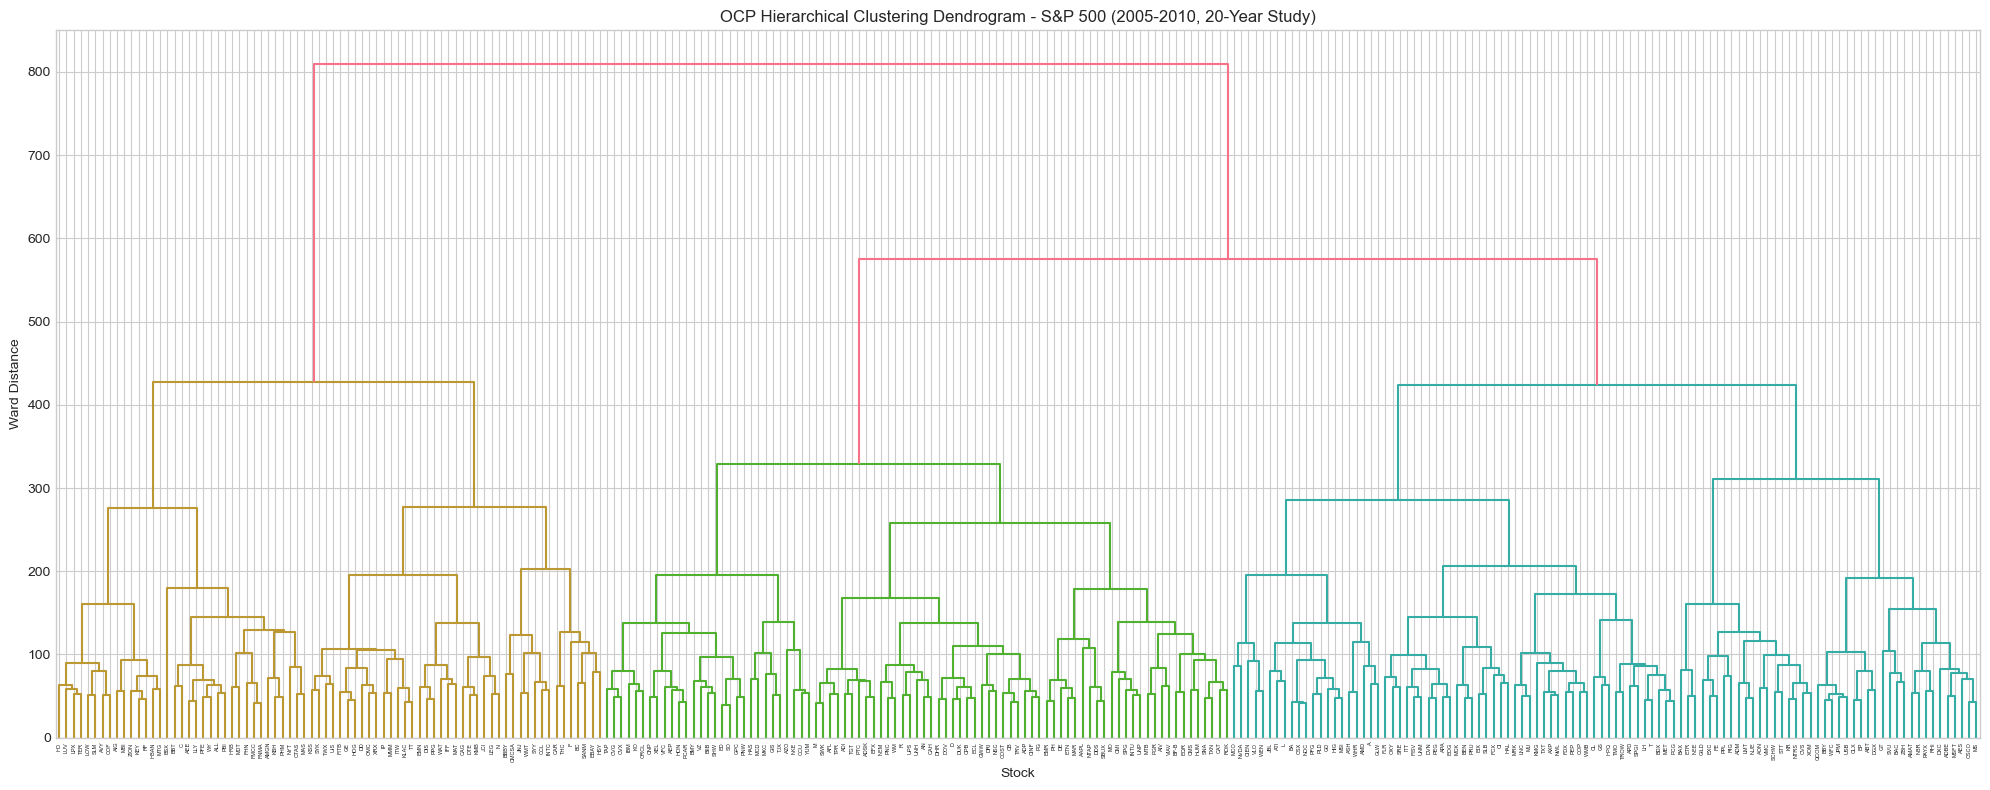


OCP cluster assignments saved to ocp_cluster_df and ocp_cluster_assignments_sp500_20y.csv
  ticker  cluster_k2  cluster_k4  cluster_k7
0      A           2           4           5
1   AAPL           2           3           4
2    ABT           2           4           7
3   ADBE           2           4           7
4    ADI           2           3           4
\OCP Cluster Validation Summary:
   k  silhouette  calinski_harabasz  davies_bouldin
0  2      0.1654            37.3271          2.3143
1  4      0.0988            23.0052          2.8889
2  7      0.0753            18.0399          2.8123


In [12]:
# OCP hierarchical clustering (k=2, 4, 7), Ward linkage
condensed_ocp = squareform(ocp_matrix)
ocp_linkage = linkage(condensed_ocp, method='ward')

ocp_clusters = {}
for k in K_VALUES:
    ocp_clusters[k] = fcluster(ocp_linkage, t=k, criterion='maxclust')
    sizes = pd.Series(ocp_clusters[k]).value_counts().sort_index()
    print(f'k={k}: cluster sizes = {sizes.tolist()}')

# Dendrogram
fig, ax = plt.subplots(figsize=(20,8))
dendrogram(ocp_linkage, labels=tickers, leaf_rotation=90, leaf_font_size=4, ax=ax)
ax.set_title('OCP Hierarchical Clustering Dendrogram - S&P 500 (2005-2010, 20-Year Study)')
ax.set_xlabel('Stock')
ax.set_ylabel('Ward Distance')
plt.tight_layout()
plt.savefig('ocp_dendrogram_sp500_20y.png', dpi=150, bbox_inches='tight')
plt.show()

# Storing cluster assignments
ocp_cluster_df = pd.DataFrame({'ticker': tickers})
for k in K_VALUES:
    ocp_cluster_df[f'cluster_k{k}'] = ocp_clusters[k]

ocp_cluster_df.to_csv('ocp_cluster_assignments_sp500_20y.csv', index=False)

print(f'\nOCP cluster assignments saved to ocp_cluster_df and ocp_cluster_assignments_sp500_20y.csv')
print(ocp_cluster_df.head())

# Cluster validation indices
ocp_cvi_results = []

for k in K_VALUES:
    labels = ocp_clusters[k]

    sil = silhouette_score(ocp_matrix, labels, metric='precomputed')
    ch = calinski_harabasz_score(train_sharpe_data.T, labels)
    db = davies_bouldin_score(train_sharpe_data.T, labels)

    ocp_cvi_results.append({
        'k': k, 
        'silhouette': sil,
        'calinski_harabasz': ch,
        'davies_bouldin': db
    })

ocp_cvi_df = pd.DataFrame(ocp_cvi_results)
print('\OCP Cluster Validation Summary:')
print(ocp_cvi_df)   

In [13]:
from scipy.special import logsumexp

TOP_TEMP = 0.5 # placeholder before tuning

def top_free_energy(x, y, T=TOP_TEMP):
    """
    Computes  the TOP (Thermal Optimal Path) free energy between two time
    series, under the same causality constraint as OCP (j >= i). As T 
    shrinks closer to 0, the cost converges to OCP's cost. 
    """
    n, m = len(x), len(y)
    log_z = np.full((n, m), -np.inf)
    log_z[0,0]  = -abs(x[0] - y[0]) /  T  # log-Boltzman-weight

    for i in range(n):
        for j in range(m):
            if j < i:
                continue
            if i == 0 and j == 0:
                continue
            preds = []
            if i > 0:
                preds.append(log_z[i - 1, j])
            if j >  0:
                preds.append(log_z[i, j - 1])
            if i > 0 and j > 0:
                preds.append(log_z[i - 1, j - 1])
            local  = -abs(x[i] - y[j]) / T
            log_z[i, j] = local + logsumexp(preds)


    return -T * log_z[n - 1, m - 1]

def top_symmetric(x, y,  T=TOP_TEMP):
    """
    Computes TOP free energy in both directions and takes the minimum,
    same process as the ocp function.
    """
    return min(top_free_energy(x, y, T), top_free_energy(y, x, T))

In [14]:
def top_pair_worker(args):
    import numpy as np
    import math

    def _logsumexp_small(vals):
        m = max(vals)
        if m == -math.inf:
            return -math.inf
        total = 0.0
        for v in vals:
            total += math.exp(v - m)
        return m + math.log(total)

    def top_free_energy(x, y, T):
        m, n = len(x), len(y)
        log_z = np.full((m, n), -np.inf)
        log_z[0, 0] = -abs(x[0] - y[0]) / T
        for ii in range(m):
            for jj in range(n):
                if ii == 0 and jj == 0:
                    continue
                if jj < ii:
                    continue
                preds = []
                if ii > 0:
                    preds.append(log_z[ii - 1, jj])
                if jj > 0:
                    preds.append(log_z[ii, jj - 1])
                if ii > 0 and jj > 0:
                    preds.append(log_z[ii - 1, jj - 1])
                local = -abs(x[ii] - y[jj]) / T
                log_z[ii, jj] = local + _logsumexp_small(preds)
        return -T * log_z[m - 1, n - 1]

    i, j, x, y, T = args

    d = min(
        top_free_energy(x, y, T),
        top_free_energy(y, x, T)
    )

    return i, j, d

tickers = train_sharpe_data.columns.tolist()
n = len(tickers)

tasks = []
for i in range(n):
    for j in range(i + 1, n):
        x = train_sharpe_data.iloc[:, i].values
        y = train_sharpe_data.iloc[:, j].values
        tasks.append((i, j, x, y, TOP_TEMP))

print(f'Total pairs to compute: {len(tasks)}')
print(f'Using {N_CORES} cores, T={TOP_TEMP}')

start_time = time.time()
top_matrix = np.zeros((n, n))

with Pool(processes=N_CORES) as pool:
    completed = 0
    for i, j, d in pool.imap_unordered(top_pair_worker, tasks, chunksize=50):
        top_matrix[i,j] = d
        top_matrix[j,i] = d
        completed += 1
        if completed % 5000 == 0:
            elapsed = time.time() - start_time
            pct = completed / len(tasks) * 100
            eta = (elapsed / completed) * (len(tasks) - completed)
            print(f' {completed:,}/{len(tasks):,} ({pct:.1f}%) - elapsed {elapsed:0f}s - ETA {eta:.0f}s')
        if completed % 10000 == 0:
            np.save('top_distance_matrix_sp500_20y_checkpoint.npy', top_matrix)
            print(f'  [checkpoint saved at {completed:,} pairs]')

elapsed = time.time() - start_time
print(f'\nTOP distance matrix computed in {elapsed:.0f} seconds ({elapsed/60:.1f} minutes)')
print(f'Matrix shape: {top_matrix.shape}')

# Saving the results to disk
np.save('top_distance_matrix_sp500_20y_train.npy', top_matrix)
pd.Series(tickers).to_csv('top_tickers_sp500_20y_train.csv', index=False)
print('\nSaved: top_distance_matrix_sp500_20y_train.npy, top_tickers_sp500_20y_train.csv, top_sharpe_data_sp500_20y_train.csv')        

Total pairs to compute: 35511
Using 10 cores, T=0.5
 5,000/35,511 (14.1%) - elapsed 100.659355s - ETA 614s
 10,000/35,511 (28.2%) - elapsed 200.223464s - ETA 511s
  [checkpoint saved at 10,000 pairs]
 15,000/35,511 (42.2%) - elapsed 297.850362s - ETA 407s
 20,000/35,511 (56.3%) - elapsed 395.560405s - ETA 307s
  [checkpoint saved at 20,000 pairs]
 25,000/35,511 (70.4%) - elapsed 492.872600s - ETA 207s
 30,000/35,511 (84.5%) - elapsed 589.919019s - ETA 108s
  [checkpoint saved at 30,000 pairs]
 35,000/35,511 (98.6%) - elapsed 688.111522s - ETA 10s

TOP distance matrix computed in 695 seconds (11.6 minutes)
Matrix shape: (267, 267)

Saved: top_distance_matrix_sp500_20y_train.npy, top_tickers_sp500_20y_train.csv, top_sharpe_data_sp500_20y_train.csv


In [15]:
print(pd.DataFrame(top_matrix[:5,:5], index=tickers[:5], columns=tickers[:5]))

            A     AAPL      ABT     ADBE      ADI
A      0.0000  49.8203  59.3712 -59.3888 -49.8408
AAPL  49.8203   0.0000 126.4255  73.9581  97.6772
ABT   59.3712 126.4255   0.0000 -30.1746  -5.5412
ADBE -59.3888  73.9581 -30.1746   0.0000 -33.8969
ADI  -49.8408  97.6772  -5.5412 -33.8969   0.0000


In [16]:
# Testing candidate temperatures on a small sample before committing to a full run

test_temperatures = [0.5, 0.25, 0.1, 0.05, 0.025, 0.01]

# Deliberately including A, AAPL, ABT, ADBE, ADI -- the exact group where
# T=0.5 produced negative values, so we can watch them directly
test_tickers = ['A', 'AAPL', 'ABT', 'ADBE', 'ADI']
test_pairs = [(i, j) for i in range(len(test_tickers)) for j in range(i + 1, len(test_tickers))]

for T in test_temperatures:
    print(f'\n--- T = {T} ---')
    any_negative = False
    for i, j in test_pairs:
        t1, t2 = test_tickers[i], test_tickers[j]
        x = train_sharpe_data[t1].values
        y = train_sharpe_data[t2].values
        args = (i, j, x, y, T)
        _, _, d = top_pair_worker(args)
        flag = '  <-- NEGATIVE' if d < 0 else ''
        if d < 0:
            any_negative = True
        print(f'  {t1}-{t2}: {d:.4f}{flag}')
    print(f'  All non-negative at T={T}: {not any_negative}')


--- T = 0.5 ---
  A-AAPL: 49.8203
  A-ABT: 59.3712
  A-ADBE: -59.3888  <-- NEGATIVE
  A-ADI: -49.8408  <-- NEGATIVE
  AAPL-ABT: 126.4255
  AAPL-ADBE: 73.9581
  AAPL-ADI: 97.6772
  ABT-ADBE: -30.1746  <-- NEGATIVE
  ABT-ADI: -5.5412  <-- NEGATIVE
  ADBE-ADI: -33.8969  <-- NEGATIVE
  All non-negative at T=0.5: False

--- T = 0.25 ---
  A-AAPL: 120.2741
  A-ABT: 132.4936
  A-ADBE: 28.7027
  A-ADI: 37.0287
  AAPL-ABT: 192.0086
  AAPL-ADBE: 141.9668
  AAPL-ADI: 162.9491
  ABT-ADBE: 51.6655
  ABT-ADI: 65.2089
  ADBE-ADI: 47.1083
  All non-negative at T=0.25: True

--- T = 0.1 ---
  A-AAPL: 145.2063
  A-ABT: 162.5833
  A-ADBE: 69.7152
  A-ADI: 76.6739
  AAPL-ABT: 218.0932
  AAPL-ADBE: 169.7132
  AAPL-ADI: 187.1146
  ABT-ADBE: 85.2759
  ABT-ADI: 98.7449
  ADBE-ADI: 81.2123
  All non-negative at T=0.1: True

--- T = 0.05 ---
  A-AAPL: 148.9007
  A-ABT: 168.6405
  A-ADBE: 78.2809
  A-ADI: 84.8584
  AAPL-ABT: 222.6147
  AAPL-ADBE: 174.6030
  AAPL-ADI: 191.2922
  ABT-ADBE: 91.9038
  ABT-ADI: 105.